# KerasCV Data Augmentation

This notebook covers **Part 1(j)** of the assignment on advanced deep learning customization.

**Topics covered:**
- **KerasCV augmentation layers**: RandAugment, CutMix, MixUp, RandomCutout, and more
- **Augmentation pipelines**: Building preprocessing pipelines for training
- **A/B comparison**: Training with vs without augmentation

**Framework:** TensorFlow/Keras with KerasCV

**Dataset:** CIFAR-10 (better suited for image augmentation than Fashion MNIST)

In [1]:
!pip install -q keras-cv tensorflow

import tensorflow as tf
from tensorflow import keras
import keras_cv
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow: {tf.__version__}")
print(f"KerasCV: {keras_cv.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 45.1 MB/s eta 0:00:00
TensorFlow: 2.19.0
KerasCV: 0.9.0


In [2]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype('float32'), X_test.astype('float32')

# Split validation set
X_val, y_val = X_train[:5000], y_train[:5000]
X_train, y_train = X_train[5000:], y_train[5000:]

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training: (45000, 32, 32, 3), Validation: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [3]:
def visualize_augmentation(images, augmenter, title, n_samples=4):
    """Displays original and augmented images side by side."""
    fig, axes = plt.subplots(2, n_samples, figsize=(12, 6))

    for i in range(n_samples):
        # Original
        axes[0, i].imshow(images[i].astype('uint8'))
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        # Augmented
        aug_img = augmenter(tf.expand_dims(images[i], 0))[0]
        axes[1, i].imshow(tf.clip_by_value(aug_img, 0, 255).numpy().astype('uint8'))
        axes[1, i].set_title('Augmented')
        axes[1, i].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

---
## Part 1: Basic KerasCV Augmentation Layers

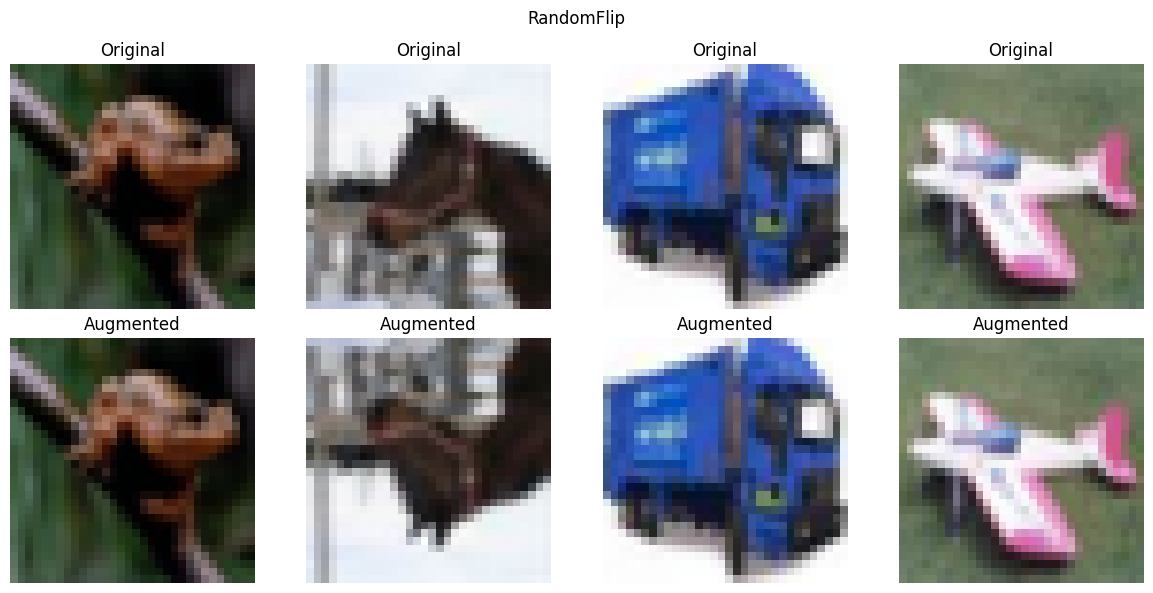

In [4]:
# RandomFlip - horizontal and vertical flipping
random_flip = keras_cv.layers.RandomFlip(mode='horizontal_and_vertical')
visualize_augmentation(X_train[:4], random_flip, 'RandomFlip')

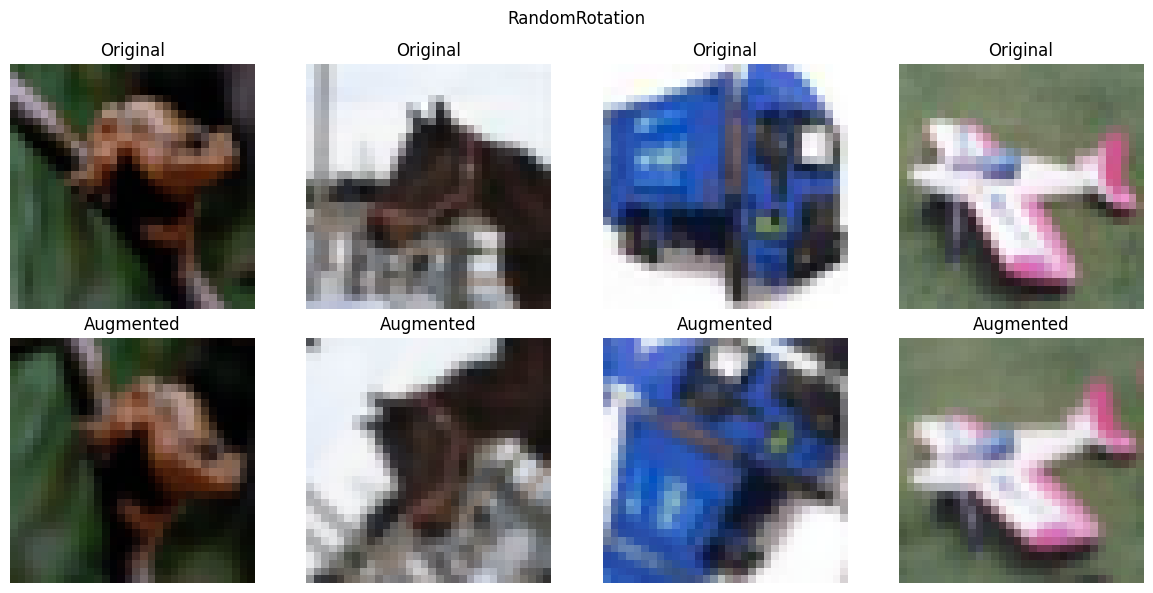

In [5]:
# RandomRotation - rotate images by random angles
random_rotation = keras_cv.layers.RandomRotation(factor=0.2)  # +/- 20% of 2*pi
visualize_augmentation(X_train[:4], random_rotation, 'RandomRotation')

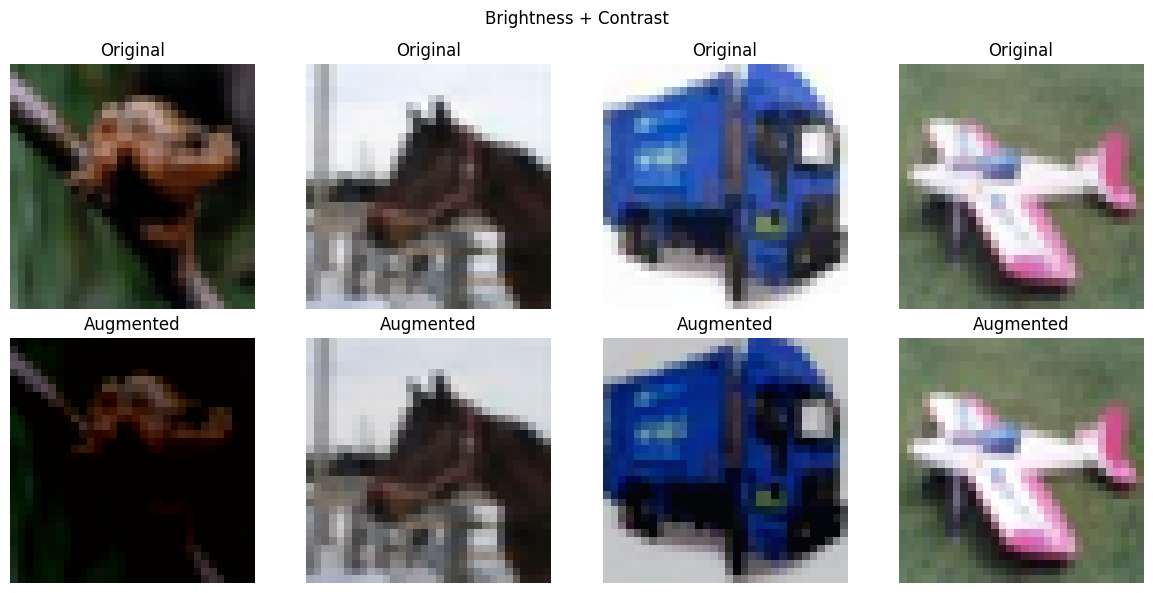

In [7]:
# RandomBrightness and RandomContrast
brightness_contrast = keras.Sequential([
    keras_cv.layers.RandomBrightness(factor=0.3),
    keras_cv.layers.RandomContrast(factor=0.3, value_range=(0, 255))
])
visualize_augmentation(X_train[:4], brightness_contrast, 'Brightness + Contrast')

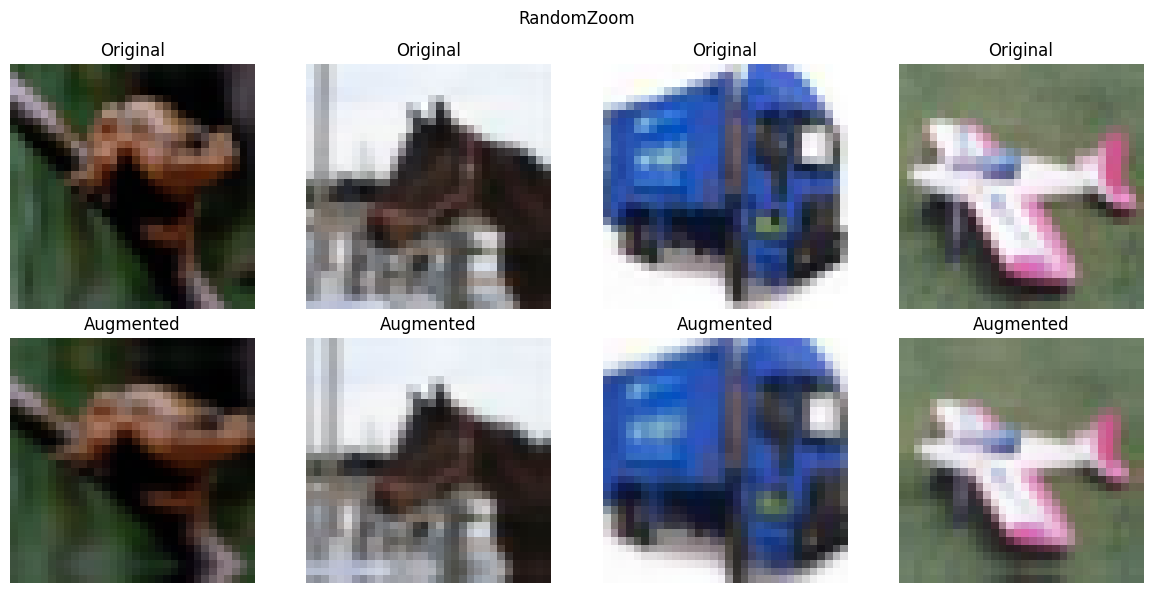

In [8]:
# RandomZoom - zoom in/out
random_zoom = keras_cv.layers.RandomZoom(height_factor=0.2, width_factor=0.2)
visualize_augmentation(X_train[:4], random_zoom, 'RandomZoom')

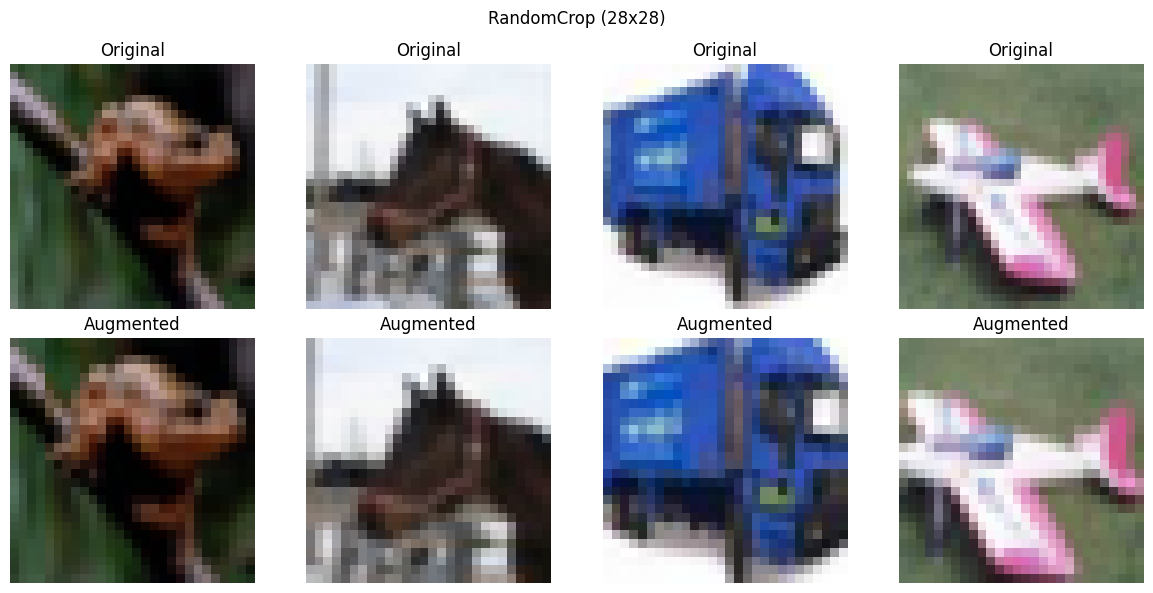

In [9]:
# RandomCrop - crop to fixed size
random_crop = keras_cv.layers.RandomCrop(height=28, width=28)
visualize_augmentation(X_train[:4], random_crop, 'RandomCrop (28x28)')

---
## Part 2: Advanced KerasCV Augmentations

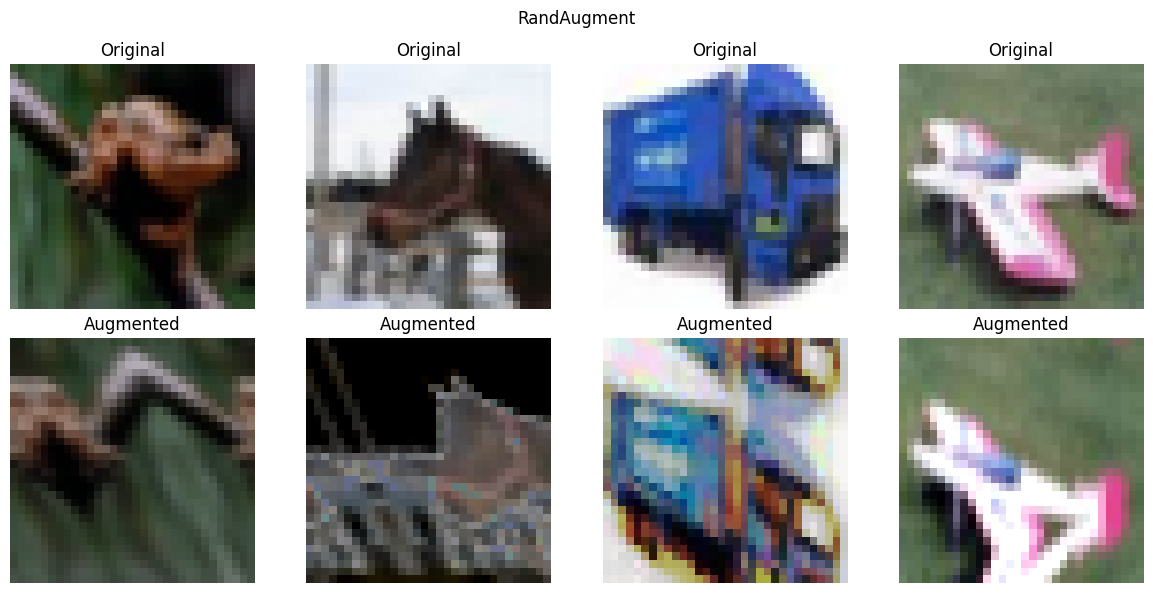

In [10]:
# RandAugment - applies a sequence of random augmentations
rand_augment = keras_cv.layers.RandAugment(
    value_range=(0, 255),
    augmentations_per_image=3,
    magnitude=0.5
)
visualize_augmentation(X_train[:4], rand_augment, 'RandAugment')

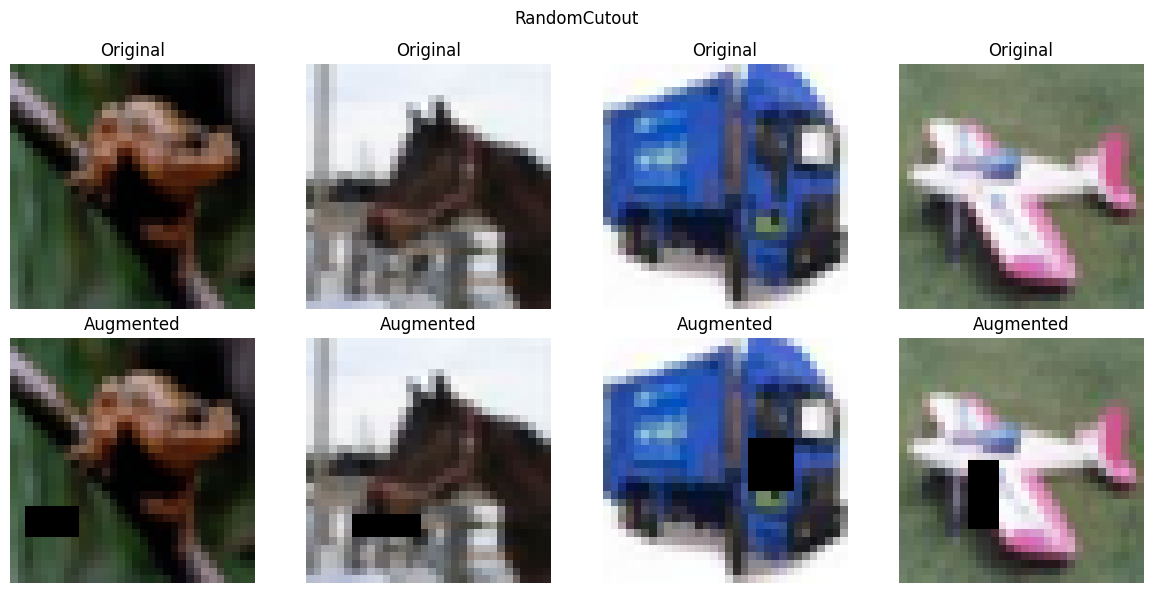

In [11]:
# RandomCutout - randomly masks out rectangular regions
random_cutout = keras_cv.layers.RandomCutout(
    height_factor=0.3,
    width_factor=0.3
)
visualize_augmentation(X_train[:4], random_cutout, 'RandomCutout')

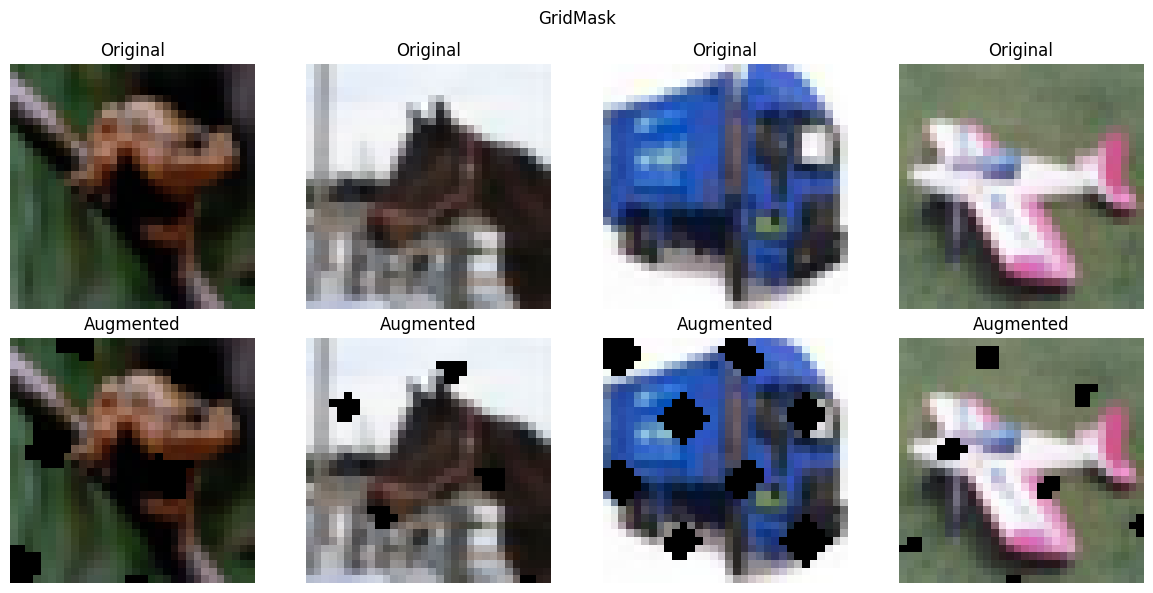

In [12]:
# GridMask - applies grid-based masking
grid_mask = keras_cv.layers.GridMask(ratio_factor=0.4)
visualize_augmentation(X_train[:4], grid_mask, 'GridMask')

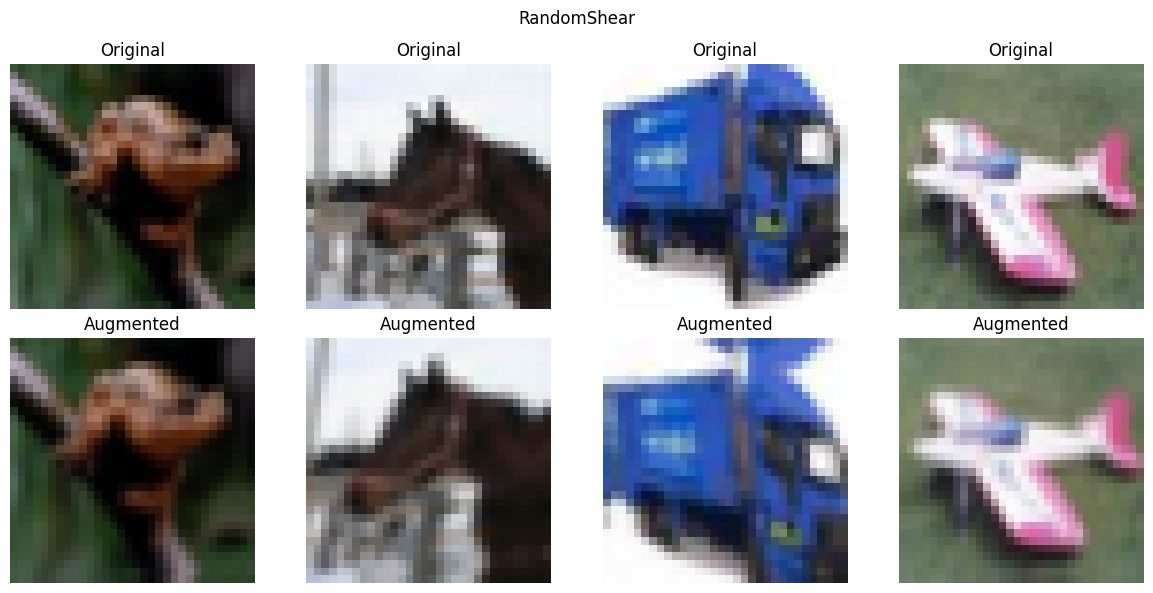

In [13]:
# RandomShear - applies shear transformation
random_shear = keras_cv.layers.RandomShear(x_factor=0.2, y_factor=0.2)
visualize_augmentation(X_train[:4], random_shear, 'RandomShear')

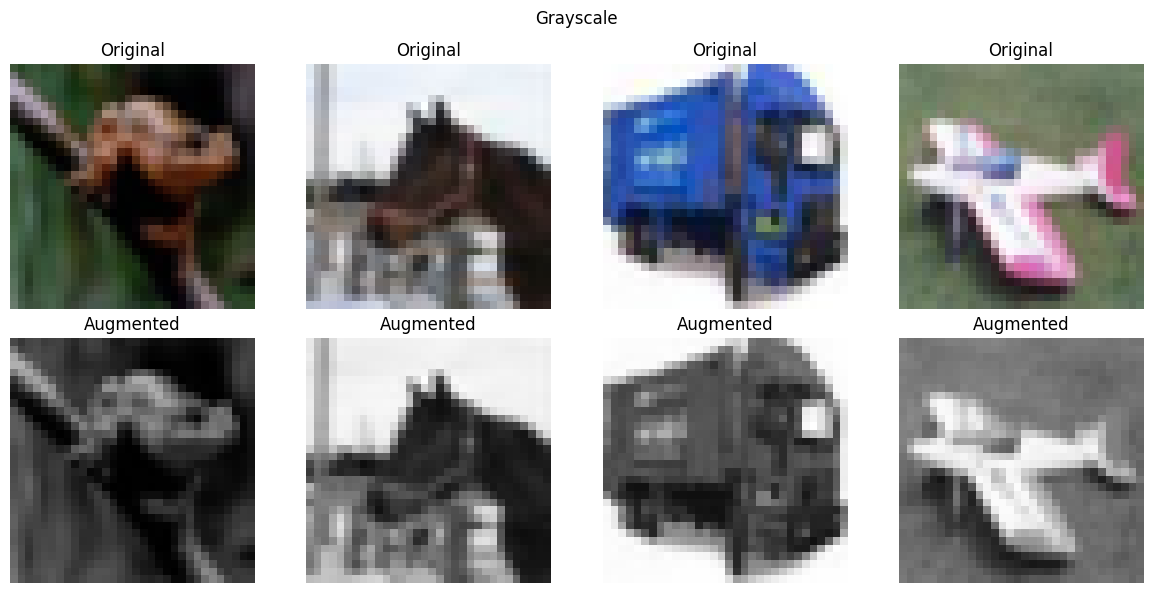

In [14]:
# Grayscale conversion
grayscale = keras_cv.layers.Grayscale(output_channels=3)
visualize_augmentation(X_train[:4], grayscale, 'Grayscale')

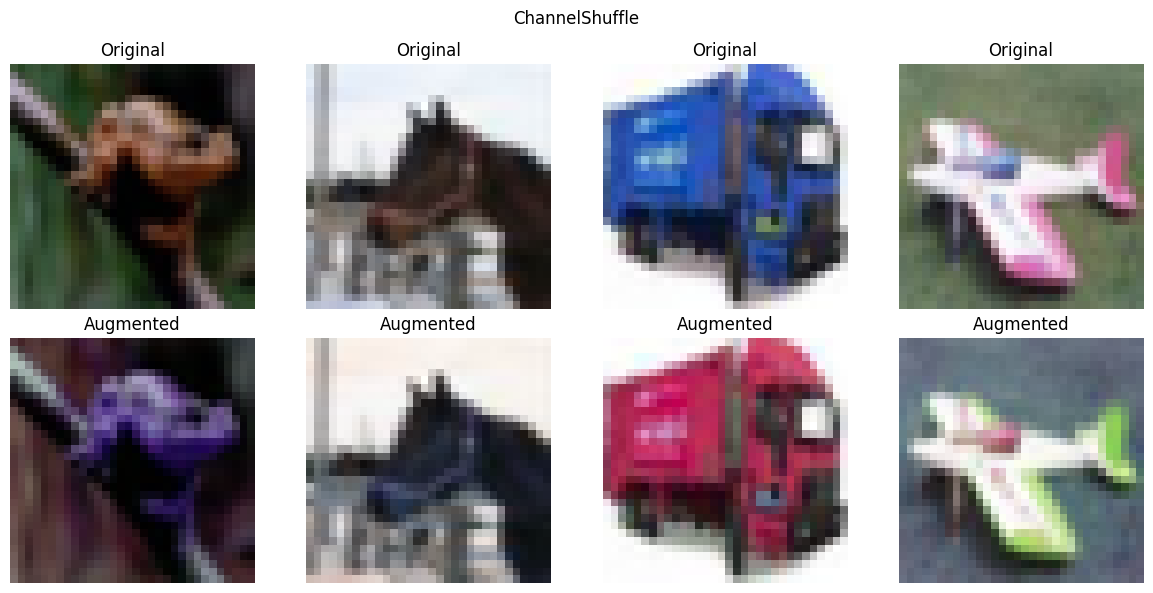

In [15]:
# ChannelShuffle - randomly shuffles color channels
channel_shuffle = keras_cv.layers.ChannelShuffle(groups=3)
visualize_augmentation(X_train[:4], channel_shuffle, 'ChannelShuffle')

---
## Part 3: CutMix and MixUp

These augmentations mix multiple images and their labels together.

In [16]:
# Prepare batch data for CutMix/MixUp visualization
batch_images = X_train[:8]
batch_labels = keras.utils.to_categorical(y_train[:8], 10)

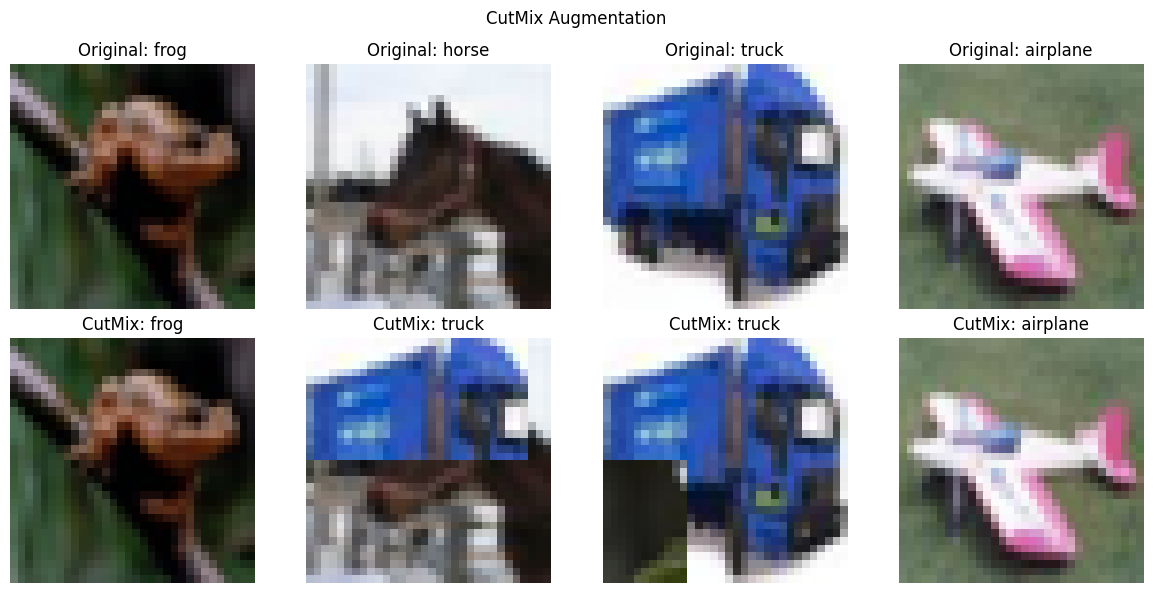

In [19]:
# CutMix - cuts and pastes patches between images
cutmix = keras_cv.layers.CutMix(alpha=1.0)

# Prepare batch data for CutMix/MixUp visualization by converting to TensorFlow Tensors
batch_images_tf = tf.convert_to_tensor(X_train[:8])
batch_labels_tf = tf.convert_to_tensor(keras.utils.to_categorical(y_train[:8], 10), dtype=tf.float32)

# CutMix requires dict input with images and labels
cutmix_input = {'images': batch_images_tf, 'labels': batch_labels_tf}
cutmix_output = cutmix(cutmix_input)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(X_train[:8][i].astype('uint8'))
    axes[0, i].set_title(f'Original: {CLASS_NAMES[y_train[i][0]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(tf.clip_by_value(cutmix_output['images'][i], 0, 255).numpy().astype('uint8'))
    top_classes = tf.argsort(cutmix_output['labels'][i], direction='DESCENDING')[:2]
    axes[1, i].set_title(f'CutMix: {CLASS_NAMES[top_classes[0]]}')
    axes[1, i].axis('off')

plt.suptitle('CutMix Augmentation')
plt.tight_layout()
plt.show()

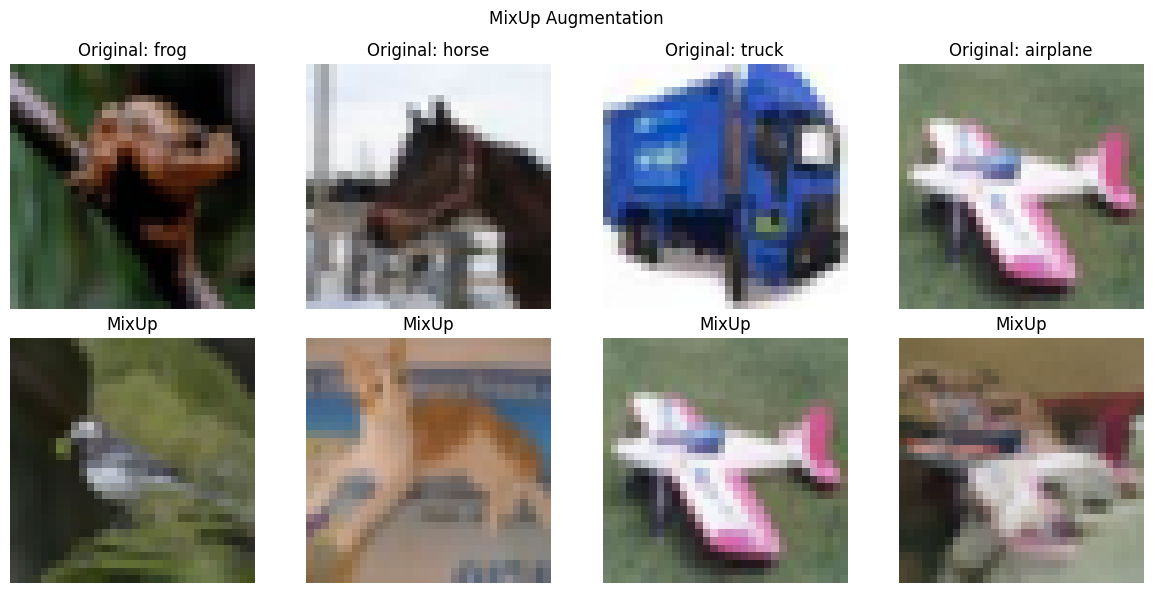

In [21]:
# MixUp - blends images and labels together
mixup = keras_cv.layers.MixUp(alpha=0.4)

# Convert batch_images and batch_labels to TensorFlow Tensors with appropriate dtype
batch_images_tf = tf.convert_to_tensor(batch_images, dtype=tf.float32)
batch_labels_tf = tf.convert_to_tensor(batch_labels, dtype=tf.float32)

mixup_input = {'images': batch_images_tf, 'labels': batch_labels_tf}
mixup_output = mixup(mixup_input)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(batch_images[i].astype('uint8'))
    axes[0, i].set_title(f'Original: {CLASS_NAMES[y_train[i][0]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(tf.clip_by_value(mixup_output['images'][i], 0, 255).numpy().astype('uint8'))
    axes[1, i].set_title('MixUp')
    axes[1, i].axis('off')

plt.suptitle('MixUp Augmentation')
plt.tight_layout()
plt.show()

---
## Part 4: Augmentation Pipeline for Training

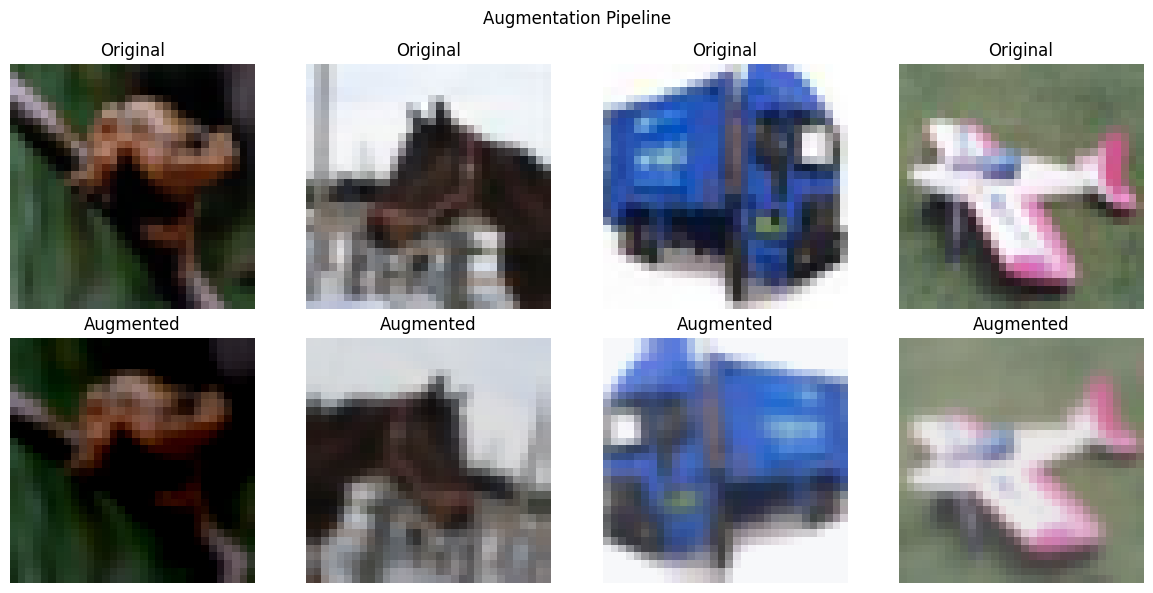

In [23]:
# Build augmentation pipeline
augmentation_pipeline = keras.Sequential([
    keras_cv.layers.RandomFlip(mode='horizontal'),
    keras_cv.layers.RandomRotation(factor=0.1),
    keras_cv.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    keras_cv.layers.RandomBrightness(factor=0.2),
    keras_cv.layers.RandomContrast(factor=0.2, value_range=(0, 255))
], name='augmentation_pipeline')

# Visualize pipeline output
visualize_augmentation(X_train[:4], augmentation_pipeline, 'Augmentation Pipeline')

In [24]:
def create_cnn_model():
    """Creates a small CNN for CIFAR-10."""
    return keras.Sequential([
        keras.layers.Rescaling(1./255),
        keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(128, 3, activation='relu', padding='same'),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(10, activation='softmax')
    ])

In [25]:
# Create tf.data datasets
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Dataset WITHOUT augmentation
train_ds_no_aug = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_no_aug = train_ds_no_aug.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Dataset WITH augmentation
train_ds_aug = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_aug = train_ds_aug.shuffle(10000).batch(BATCH_SIZE)
train_ds_aug = train_ds_aug.map(lambda x, y: (augmentation_pipeline(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds_aug = train_ds_aug.prefetch(AUTOTUNE)

# Validation dataset (no augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

---
## Part 5: A/B Comparison - With vs Without Augmentation

In [26]:
# Train WITHOUT augmentation
print("Training WITHOUT augmentation...")
model_no_aug = create_cnn_model()
model_no_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_no_aug = model_no_aug.fit(
    train_ds_no_aug,
    epochs=15,
    validation_data=val_ds,
    verbose=1
)

Training WITHOUT augmentation...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.2937 - loss: 1.8494 - val_accuracy: 0.3810 - val_loss: 1.6481
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4175 - loss: 1.5641 - val_accuracy: 0.4554 - val_loss: 1.4539
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4791 - loss: 1.4224 - val_accuracy: 0.5142 - val_loss: 1.3071
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5173 - loss: 1.3303 - val_accuracy: 0.5436 - val_loss: 1.2787
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5424 - loss: 1.2612 - val_accuracy: 0.5856 - val_loss: 1.1507
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5689 - loss: 1.1904 - val_accuracy: 0.6048 - val_loss: 1.1118
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5912 - loss: 1.1426 - val_accuracy: 0.6190 - val_loss: 1.0868
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.606

In [27]:
# Train WITH augmentation
print("\nTraining WITH augmentation...")
model_aug = create_cnn_model()
model_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_aug = model_aug.fit(
    train_ds_aug,
    epochs=15,
    validation_data=val_ds,
    verbose=1
)


Training WITH augmentation...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2320 - loss: 2.0117 - val_accuracy: 0.3136 - val_loss: 1.8013
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3173 - loss: 1.8084 - val_accuracy: 0.3568 - val_loss: 1.7391
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3762 - loss: 1.6789 - val_accuracy: 0.4078 - val_loss: 1.6333
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4222 - loss: 1.5818 - val_accuracy: 0.4354 - val_loss: 1.5195
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4466 - loss: 1.5125 - val_accuracy: 0.4648 - val_loss: 1.4863
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4660 - loss: 1.4651 - val_accuracy: 0.5276 - val_loss: 1.2834
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4847 - loss: 1.4217 - val_accuracy: 0.5132 - val_loss: 1.3450
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4998 -

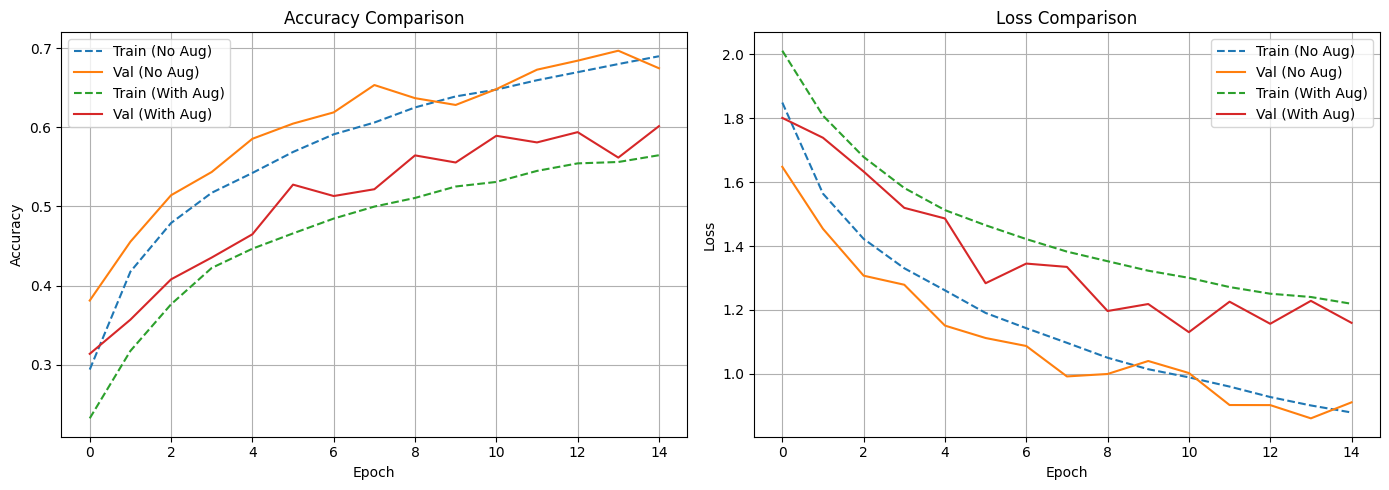

In [28]:
# Compare training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_no_aug.history['accuracy'], label='Train (No Aug)', linestyle='--')
axes[0].plot(history_no_aug.history['val_accuracy'], label='Val (No Aug)')
axes[0].plot(history_aug.history['accuracy'], label='Train (With Aug)', linestyle='--')
axes[0].plot(history_aug.history['val_accuracy'], label='Val (With Aug)')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss comparison
axes[1].plot(history_no_aug.history['loss'], label='Train (No Aug)', linestyle='--')
axes[1].plot(history_no_aug.history['val_loss'], label='Val (No Aug)')
axes[1].plot(history_aug.history['loss'], label='Train (With Aug)', linestyle='--')
axes[1].plot(history_aug.history['val_loss'], label='Val (With Aug)')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Final evaluation on test set
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

_, acc_no_aug = model_no_aug.evaluate(test_ds, verbose=0)
_, acc_aug = model_aug.evaluate(test_ds, verbose=0)

print("\n" + "="*50)
print("Test Set Results:")
print(f"  Without Augmentation: {acc_no_aug:.4f}")
print(f"  With Augmentation:    {acc_aug:.4f}")
print(f"  Improvement:          {(acc_aug - acc_no_aug)*100:.2f}%")
print("="*50)


Test Set Results:
  Without Augmentation: 0.6663
  With Augmentation:    0.5841
  Improvement:          -8.22%


---
## Part 6: RandAugment Training

In [30]:
# RandAugment pipeline
rand_augment_pipeline = keras_cv.layers.RandAugment(
    value_range=(0, 255),
    augmentations_per_image=2,
    magnitude=0.3
)

train_ds_randaug = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds_randaug = train_ds_randaug.shuffle(10000).batch(BATCH_SIZE)
train_ds_randaug = train_ds_randaug.map(lambda x, y: (rand_augment_pipeline(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds_randaug = train_ds_randaug.prefetch(AUTOTUNE)

In [31]:
print("Training with RandAugment...")
model_randaug = create_cnn_model()
model_randaug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_randaug = model_randaug.fit(
    train_ds_randaug,
    epochs=15,
    validation_data=val_ds,
    verbose=1
)

_, acc_randaug = model_randaug.evaluate(test_ds, verbose=0)
print(f"\nRandAugment Test Accuracy: {acc_randaug:.4f}")

Training with RandAugment...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.2078 - loss: 2.0747 - val_accuracy: 0.3352 - val_loss: 1.7493
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.3198 - loss: 1.8275 - val_accuracy: 0.4472 - val_loss: 1.5078
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.3781 - loss: 1.6984 - val_accuracy: 0.4848 - val_loss: 1.4139
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.4143 - loss: 1.6031 - val_accuracy: 0.5354 - val_loss: 1.2759
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.4340 - loss: 1.5494 - val_accuracy: 0.5606 - val_loss: 1.2242
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.4579 - loss: 1.4970 - val_accuracy: 0.5632 - val_loss: 1.2109
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.4730 - loss: 1.4582 - val_accuracy: 0.5778 - val_loss: 1.1615
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accur

---
## Summary

| Augmentation | Description | Use Case |
|--------------|-------------|----------|
| **RandomFlip** | Horizontal/vertical flip | General image classification |
| **RandomRotation** | Random rotation | Objects with rotational variance |
| **RandomZoom** | Scale in/out | Multi-scale recognition |
| **RandomCutout** | Mask rectangular regions | Occlusion robustness |
| **RandAugment** | Auto-selected augmentations | General-purpose, minimal tuning |
| **CutMix** | Cut and paste patches + mix labels | Strong regularization |
| **MixUp** | Blend images and labels | Smoother decision boundaries |
| **GridMask** | Grid-based masking | Structured occlusion robustness |